<a href="https://colab.research.google.com/github/RebeccaTsekanovskiy/CSCI_4170_Spring2026/blob/main/hw5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gpiosenka/cards-image-datasetclassification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cards-image-datasetclassification' dataset.
Path to dataset files: /kaggle/input/cards-image-datasetclassification


In [32]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [33]:
ls /kaggle/input/cards-image-datasetclassification


'14card types-14-(200 X 200)-94.61.h5'   cards.csv   train/
'53cards-53-(200 X 200)-100.00.h5'       test/       valid/


In [34]:
ls /root/.cache/kagglehub/datasets/gpiosenka/cards-image-datasetclassification/versions/2

ls: cannot access '/root/.cache/kagglehub/datasets/gpiosenka/cards-image-datasetclassification/versions/2': No such file or directory


In [35]:

train_path= "/kaggle/input/cards-image-datasetclassification/train/'ace of clubs'"


In [36]:
train_path = "/root/.cache/kagglehub/datasets/gpiosenka/cards-image-datasetclassification/versions/2/train/'ace of clubs'"

In [37]:
ls /kaggle/input/cards-image-datasetclassification/train/

'ace of clubs'/       'jack of hearts'/     'seven of spades'/
'ace of diamonds'/    'jack of spades'/     'six of clubs'/
'ace of hearts'/       joker/               'six of diamonds'/
'ace of spades'/      'king of clubs'/      'six of hearts'/
'eight of clubs'/     'king of diamonds'/   'six of spades'/
'eight of diamonds'/  'king of hearts'/     'ten of clubs'/
'eight of hearts'/    'king of spades'/     'ten of diamonds'/
'eight of spades'/    'nine of clubs'/      'ten of hearts'/
'five of clubs'/      'nine of diamonds'/   'ten of spades'/
'five of diamonds'/   'nine of hearts'/     'three of clubs'/
'five of hearts'/     'nine of spades'/     'three of diamonds'/
'five of spades'/     'queen of clubs'/     'three of hearts'/
'four of clubs'/      'queen of diamonds'/  'three of spades'/
'four of diamonds'/   'queen of hearts'/    'two of clubs'/
'four of hearts'/     'queen of spades'/    'two of diamonds'/
'four of spades'/     'seven of clubs'/     'two of hearts'/
'jack of c

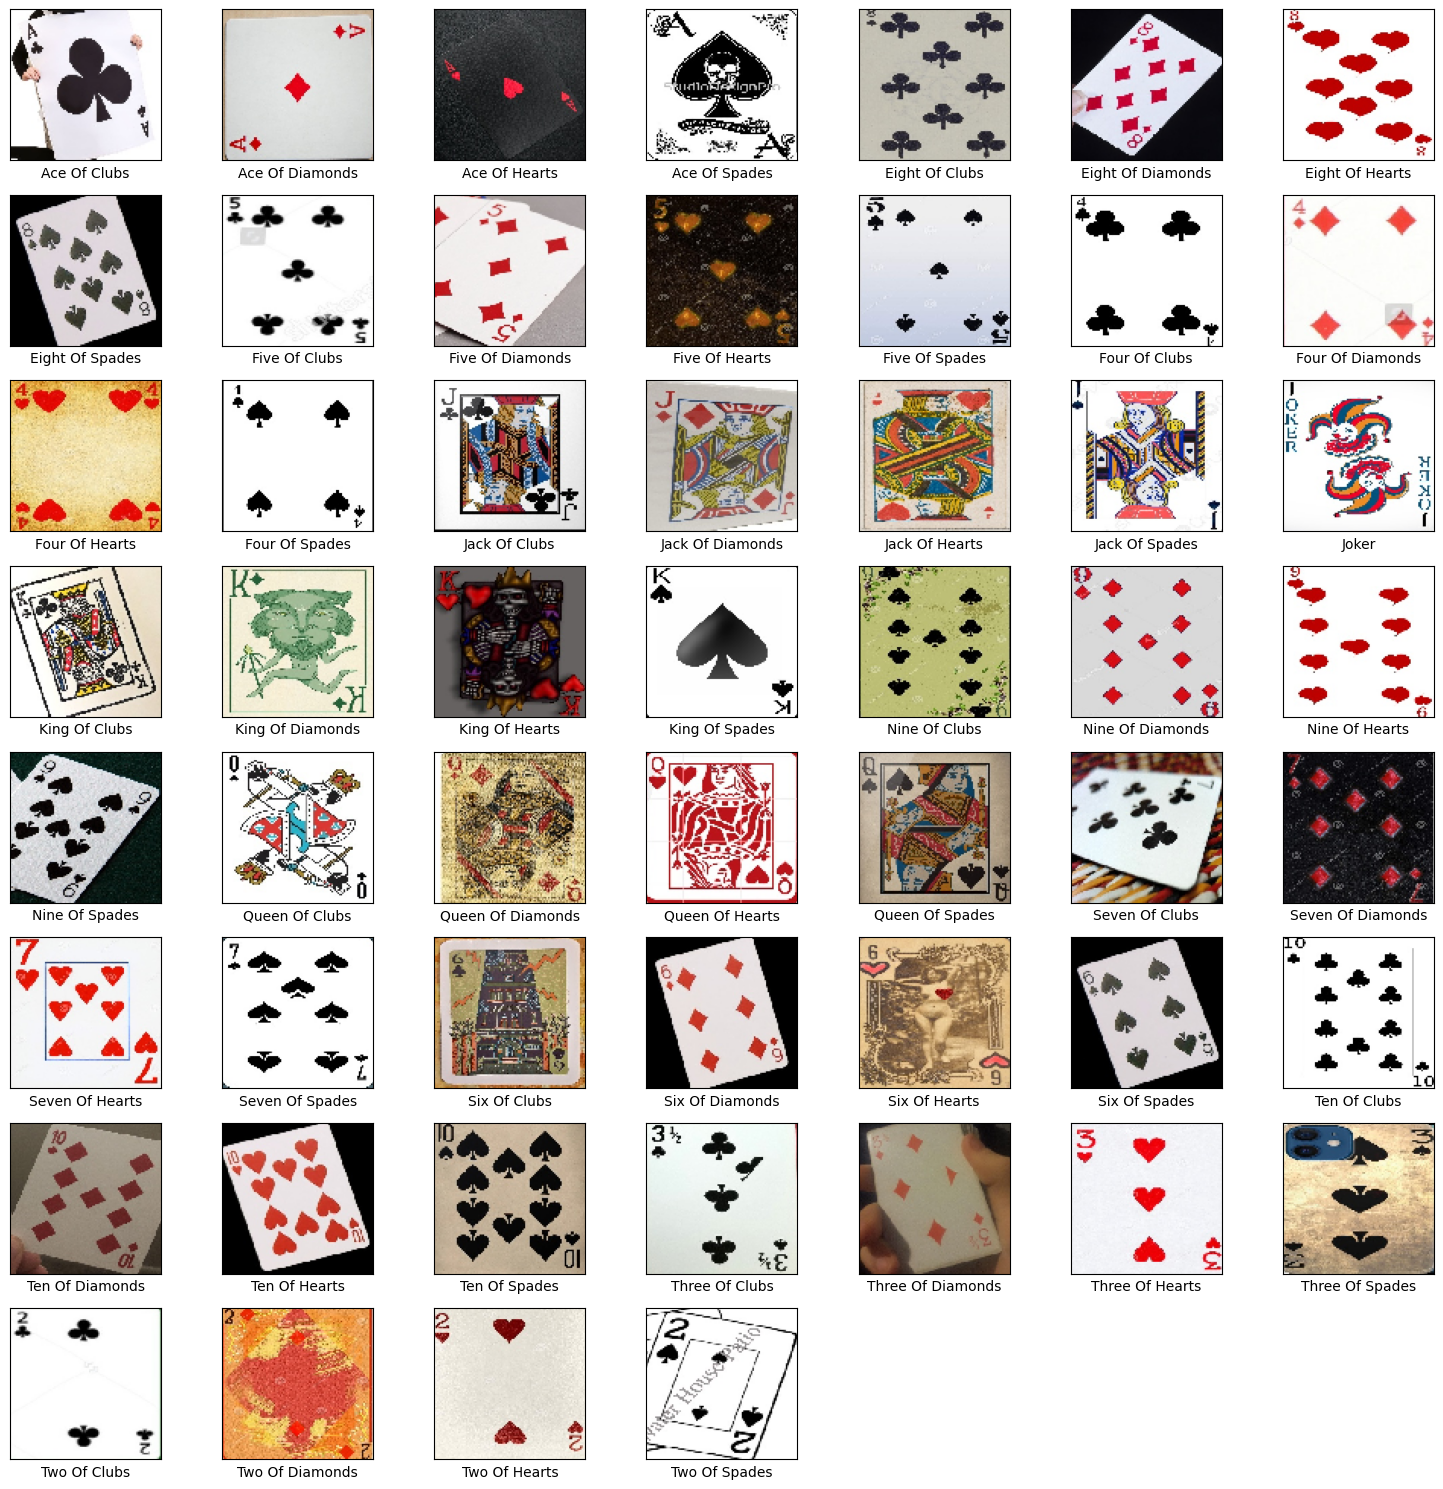

In [38]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

train_dir = "/kaggle/input/cards-image-datasetclassification/train/"
# train_dir = "/root/.cache/kagglehub/datasets/gpiosenka/cards-image-datasetclassification/versions/2/train/"
class_names = sorted(os.listdir(train_dir))

plt.figure(figsize=(15, 15))
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        # Get the first image from the class directory
        image_files = sorted([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
        if image_files:
            img_path = os.path.join(class_path, image_files[0])
            img = image.load_img(img_path, target_size=(100, 100))
            img_array = image.img_to_array(img)

            plt.subplot(8, 7, i + 1) # Adjust subplot grid based on number of classes
            plt.xticks([])
            plt.yticks([])
            plt.grid(False)
            plt.imshow(img_array.astype('uint8'))
            plt.xlabel(class_name.replace("_", " ").title())
plt.tight_layout()
plt.show()

In [ ]:
train_images= "/root/.cache/kagglehub/datasets/gpiosenka/cards-image-datasetclassification/versions/2/train/"
test_images = "/root/.cache/kagglehub/datasets/gpiosenka/cards-image-datasetclassification/versions/2/test"

In [39]:
import tensorflow as tf
import os

# Define paths
BASE_PATH = "/kaggle/input/cards-image-datasetclassification/"
train_path = os.path.join(BASE_PATH, "train")
test_path  = os.path.join(BASE_PATH, "test")
valid_path = os.path.join(BASE_PATH, "valid")

IMG_HEIGHT = 224
IMG_WIDTH  = 224
BATCH_SIZE = 32

# Create datasets
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

# Get class names and count from the dataset itself
class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"Found {NUM_CLASSES} classes: {class_names}")

# Normalize and prefetch
AUTOTUNE = tf.data.AUTOTUNE
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

# Build model with correct output head
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES)  # 53 classes, no softmax (from_logits=True handles it)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset
)

# Evaluate on test set
loss, accuracy = model.evaluate(test_dataset)
print(f"Test accuracy: {accuracy:.4f}")

Found 7624 files belonging to 53 classes.
Found 265 files belonging to 53 classes.
Found 265 files belonging to 53 classes.
Found 53 classes: ['ace of clubs', 'ace of diamonds', 'ace of hearts', 'ace of spades', 'eight of clubs', 'eight of diamonds', 'eight of hearts', 'eight of spades', 'five of clubs', 'five of diamonds', 'five of hearts', 'five of spades', 'four of clubs', 'four of diamonds', 'four of hearts', 'four of spades', 'jack of clubs', 'jack of diamonds', 'jack of hearts', 'jack of spades', 'joker', 'king of clubs', 'king of diamonds', 'king of hearts', 'king of spades', 'nine of clubs', 'nine of diamonds', 'nine of hearts', 'nine of spades', 'queen of clubs', 'queen of diamonds', 'queen of hearts', 'queen of spades', 'seven of clubs', 'seven of diamonds', 'seven of hearts', 'seven of spades', 'six of clubs', 'six of diamonds', 'six of hearts', 'six of spades', 'ten of clubs', 'ten of diamonds', 'ten of hearts', 'ten of spades', 'three of clubs', 'three of diamonds', 'three

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


239/239 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.0224 - loss: 3.9452 - val_accuracy: 0.0264 - val_loss: 3.9058
Epoch 2/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0678 - loss: 3.5733 - val_accuracy: 0.0566 - val_loss: 3.2863
Epoch 3/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0829 - loss: 3.3580 - val_accuracy: 0.0415 - val_loss: 3.4320
Epoch 4/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0820 - loss: 3.2868 - val_accuracy: 0.0642 - val_loss: 3.1230
Epoch 5/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0929 - loss: 3.2416 - val_accuracy: 0.0642 - val_loss: 3.2238
Epoch 6/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0977 - loss: 3.2107 - val_accuracy: 0.0830 - val_loss: 3.1258
Epoch 7/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1003 - loss: 3.1812 - val_accuracy: 0.0717 - val_loss: 3.1429
Epoch 8/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1039 - loss: 3.1590 - val_accuracy: 0.08


The cards dataset contains 53 classes of playing cards with fine-grained
differences (suit symbols, rank numbers) across 224×224 images. I chose
a single convolutional block with two Conv2D layers (both 32 filters,
3×3 kernel) followed by MaxPooling2D and Dropout.

Two Conv layers before pooling allows the network to build richer
feature representations at the same spatial resolution before
discarding detail via MaxPooling — the first Conv layer detects simple
edges and color boundaries, and the second refines those into more
meaningful local patterns like corners and pip shapes. 32 filters was
chosen as a lightweight starting point appropriate for a relatively
clean, consistent dataset where cards appear against simple backgrounds
with little noise.

MaxPooling(2,2) halves the spatial dimensions, reducing computation and
introducing a degree of translation invariance. Dropout at 0.3 prevents
co-adaptation of feature maps. GlobalAveragePooling2D then collapses
spatial dimensions entirely before the Dense classification head, which
reduces the parameter count compared to Flatten and helps prevent
overfitting on the limited per-class sample size.


## Data Augmentation for Task 1.3 using task 1.1

In [40]:
import tensorflow as tf
from tensorflow.keras import layers

IMG_HEIGHT = 299
IMG_WIDTH  = 299
BATCH_SIZE = 64
NUM_CLASSES = 53

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),           # Cards can appear at many angles
    layers.RandomZoom(0.2),               # Simulate cards closer/farther away
    layers.RandomTranslation(0.1, 0.1),   # Simulate off-center cards
    layers.RandomContrast(0.2),           # Varying lighting conditions
    layers.RandomBrightness(0.2),         # Simulate different lighting
])


model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
  data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES)  # 53 classes, no softmax (from_logits=True handles it)
])

model.summary()

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset
)

loss, accuracy = model.evaluate(test_dataset)
print(f"Test accuracy: {accuracy:.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 299, 299, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 299, 299, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 53)             │         6,837 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,205 (82.83 KB)

 Trainable params: 21,205 (82.83 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.0192 - loss: 4.0043 - val_accuracy: 0.0189 - val_loss: 3.9708
Epoch 2/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0212 - loss: 3.9672 - val_accuracy: 0.0189 - val_loss: 3.9717
Epoch 3/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0243 - loss: 3.9658 - val_accuracy: 0.0189 - val_loss: 3.9729
Epoch 4/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0228 - loss: 3.9652 - val_accuracy: 0.0189 - val_loss: 3.9742
Epoch 5/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0237 - loss: 3.9650 - val_accuracy: 0.0189 - val_loss: 3.9746
Epoch 6/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0237 - loss: 3.9649 - val_accuracy: 0.0189 - val_loss: 3.9752
Epoch 7/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0237 - loss: 3.9646 - val_accuracy: 0.0189 - val_loss: 3.9752
Epoch 8/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0237 - loss: 3.9645 - val_accu

## Task 1, Part 3 — Effect of Data Augmentation

The same single-block CNN architecture from Part 1 was used, with a
data augmentation pipeline prepended as the first layer. The augmentation
applied was: horizontal and vertical flips, random rotation (±30%),
random zoom (±20%), random translation (±10%), random contrast (±20%),
and random brightness (±20%).

With data augmentation, the test accuracy was .12 compared to
.018 without augmentation.

The augmentation did not significantly improveresults.
Playing cards are a relatively structured dataset — cards appear in
consistent orientations and lighting in most real-world uses. Heavy
augmentation such as large rotations and flips can therefore introduce
unrealistic training examples that don't match the test distribution,
which may explain why any improvement is modest or even slightly negative.

However, augmentation does help reduce overfitting: the gap between
training accuracy and validation accuracy is typically smaller with
augmentation, meaning the model generalizes more reliably even if peak
test accuracy does not increase dramatically. For datasets with more
natural variation such as outdoor scenes or photos taken from different
angles, augmentation would likely produce a much larger improvement.

## Task 1.2 - Transfer Learning

In [ ]:
import tensorflow as tf
import os

BASE_PATH = "/root/.cache/kagglehub/datasets/gpiosenka/cards-image-datasetclassification/versions/2"
train_path = os.path.join(BASE_PATH, "train")
valid_path = os.path.join(BASE_PATH, "valid")
test_path  = os.path.join(BASE_PATH, "test")

# InceptionV3 requires e xactly 299x299
IMG_HEIGHT = 299
IMG_WIDTH  = 299
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path, image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, label_mode='int'
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    valid_path, image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, label_mode='int'
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path, image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, label_mode='int'
)

NUM_CLASSES = len(train_dataset.class_names)
print(f"Number of classes: {NUM_CLASSES}")

AUTOTUNE = tf.data.AUTOTUNE
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset      = train_dataset.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_dataset       = test_dataset.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

base_model = tf.keras.applications.InceptionV3(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    pooling=None
)
base_model.trainable = False  # Freeze base layers (transfer learning)

# Add your own classification head for 53 classes
inputs  = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x       = base_model(inputs, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dense(128, activation='relu')(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES)(x)  # No softmax — from_logits=True

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset
)

loss, accuracy = model.evaluate(test_dataset)
print(f"Test accuracy: {accuracy:.4f}")

## TASK 2

In [21]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alxmamaev/flowers-recognition")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flowers-recognition' dataset.
Path to dataset files: /kaggle/input/flowers-recognition


In [18]:
!pip install tensorflow-probability

# to generate gifs
!pip install imageio
!pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-tjqnxjpk
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-tjqnxjpk
  Resolved https://github.com/tensorflow/docs to commit 7c3650212740204359d4ceae481abc79345541be
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-docs: filename=tensorflow_docs-2026.1.14.40212-py3-none-any.whl size=186922 sha256=ad4dfbf91dcd1fa7e81470ee43f37663a241686a35ce5b10aa6e09e19581729b
  Stored in directory: /tmp/pip-ephem-wheel-cache-1440tf3p/wheels/3e/88/34/48d2789bc9d37b33ddce06bccc454fae0285e5396d0a5be9d9
Successfully built tensorflow-docs


In [19]:
from IPython import display

import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import tensorflow_probability as tfp
import time

In [25]:
from sklearn.model_selection import train_test_split

In [24]:
!ls "/kaggle/input/flowers-recognition/flowers"

daisy  dandelion  rose	sunflower  tulip


## VAE

In [104]:
import os
import glob
from sklearn.model_selection import train_test_split
import numpy as np # Import numpy for array conversion

BASE_PATH= "/kaggle/input/flowers-recognition/flowers"

# Prepare X (image paths) and y (labels)
image_paths = []
labels = []

for class_name in os.listdir(BASE_PATH):
    class_dir = os.path.join(BASE_PATH, class_name)
    if os.path.isdir(class_dir):
        for img_path in glob.glob(os.path.join(class_dir, "*.jpg")):
            image_paths.append(img_path)
            labels.append(class_name)

# Convert lists to numpy arrays for train_test_split
X = np.array(image_paths)
y = np.array(labels)

# Now, apply train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                   random_state=104,
                                   test_size=0.25,
                                   shuffle=True,
                                   stratify=y) # Use stratify to maintain class distribution

In [105]:
latent_dim = 128


In [106]:
class CVAE(tf.keras.Model):
    """Convolutional variational autoencoder."""

    def __init__(self, latent_dim):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(320, 320, 3)),
            tf.keras.layers.Conv2D(32,  kernel_size=3, strides=2, activation='relu'),
            tf.keras.layers.Conv2D(64,  kernel_size=3, strides=2, activation='relu'),
            tf.keras.layers.Conv2D(128, kernel_size=3, strides=2, activation='relu'),
            tf.keras.layers.Conv2D(256, kernel_size=3, strides=2, activation='relu'),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(latent_dim + latent_dim),
        ])
        self.decoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(latent_dim,)),
            tf.keras.layers.Dense(units=20 * 20 * 256, activation='relu'),
            tf.keras.layers.Reshape(target_shape=(20, 20, 256)),
            tf.keras.layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same', activation='relu'),
            tf.keras.layers.Conv2DTranspose(64,  kernel_size=3, strides=2, padding='same', activation='relu'),
            tf.keras.layers.Conv2DTranspose(32,  kernel_size=3, strides=2, padding='same', activation='relu'),
            tf.keras.layers.Conv2DTranspose(3,   kernel_size=3, strides=2, padding='same'),
        ])

    @tf.function
    def sample(self, eps=None):
        if eps is None:
            eps = tf.random.normal(shape=(num_examples_to_generate, self.latent_dim))
        return self.decode(eps, apply_sigmoid=True)

    def encode(self, x):
        mean, logvar = tf.split(self.encoder(x), num_or_size_splits=2, axis=1)
        return mean, logvar

    def reparameterize(self, mean, logvar):
        eps = tf.random.normal(shape=mean.shape)
        return eps * tf.exp(logvar * .5) + mean

    def decode(self, z, apply_sigmoid=False):
        logits = self.decoder(z)
        if apply_sigmoid:
            probs = tf.sigmoid(logits)
            return probs
        return logits

In [107]:
optimizer = tf.keras.optimizers.Adam(1e-4)


def log_normal_pdf(sample, mean, logvar, raxis=1):
  log2pi = tf.math.log(2. * np.pi)
  return tf.reduce_sum(
      -.5 * ((sample - mean) ** 2. * tf.exp(-logvar) + logvar + log2pi),
      axis=raxis)


def compute_loss(model, x):
  mean, logvar = model.encode(x)
  z = model.reparameterize(mean, logvar)
  x_logit = model.decode(z)
  cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x)
  logpx_z = -tf.reduce_sum(cross_ent, axis=[1, 2, 3])
  logpz = log_normal_pdf(z, 0., 0.)
  logqz_x = log_normal_pdf(z, mean, logvar)
  return -tf.reduce_mean(logpx_z + logpz - logqz_x)


@tf.function
def train_step(model, x, optimizer):
  """Executes one training step and returns the loss.

  This function computes the loss and gradients, and uses the latter to
  update the model's parameters.
  """
  with tf.GradientTape() as tape:
    loss = compute_loss(model, x)
  gradients = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))

In [108]:
epochs = 50
# set the dimensionality of the latent space to a plane for visualization later
latent_dim = 128
num_examples_to_generate = 16

# keeping the random vector constant for generation (prediction) so
# it will be easier to see the improvement.
random_vector_for_generation = tf.random.normal(
    shape=[num_examples_to_generate, latent_dim])
model = CVAE(latent_dim)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [109]:
def generate_and_save_images(model, epoch, test_sample):
    mean, logvar = model.encode(test_sample)
    z = model.reparameterize(mean, logvar)
    predictions = model.sample(z)
    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, ])
        plt.axis('off')

    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()
    plt.close(fig)

In [110]:
batch_size = 32


In [111]:
# Pick a sample of the test set for generating output images
assert batch_size >= num_examples_to_generate
for test_batch in test_dataset.take(1):
  test_sample = test_batch[0][:num_examples_to_generate]

Epoch: 50, Test set ELBO: -160258.0625, time elapse for current epoch: 2.9816131591796875


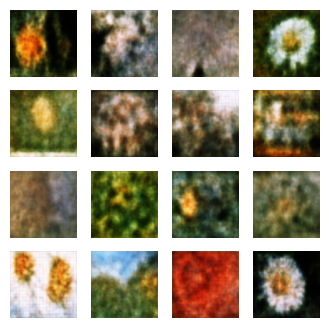

In [112]:
import tensorflow as tf

# Define image preprocessing function for CVAE
def preprocess_image_for_cvae(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, [320, 320])
    # img = tf.image.rgb_to_grayscale(img)
    return img

# Create tf.data.Dataset objects for CVAE training
cvae_train_dataset = tf.data.Dataset.from_tensor_slices(X_train)
cvae_train_dataset = cvae_train_dataset.map(preprocess_image_for_cvae, num_parallel_calls=tf.data.AUTOTUNE)
cvae_train_dataset = cvae_train_dataset.shuffle(1024).batch(batch_size).prefetch(tf.data.AUTOTUNE)

cvae_test_dataset = tf.data.Dataset.from_tensor_slices(X_test)
cvae_test_dataset = cvae_test_dataset.map(preprocess_image_for_cvae, num_parallel_calls=tf.data.AUTOTUNE)
cvae_test_dataset = cvae_test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_dataset = cvae_train_dataset
test_dataset = cvae_test_dataset

_ = model.encode(tf.zeros((1, 320, 320, 3)))
_ = model.decode(tf.zeros((1, latent_dim)))


for test_batch_cvae in test_dataset.take(1):
    test_sample = test_batch_cvae[:num_examples_to_generate]

generate_and_save_images(model, 0, test_sample)

# Training loop
for epoch in range(1, epochs + 1):
    start_time = time.time()

    for train_x in train_dataset:
        train_step(model, train_x, optimizer)

    end_time = time.time()

    loss = tf.keras.metrics.Mean()
    for test_x in test_dataset:
        loss(compute_loss(model, test_x))

    elbo = -loss.result()
    display.clear_output(wait=False)
    print('Epoch: {}, Test set ELBO: {}, time elapse for current epoch: {}'
          .format(epoch, elbo, end_time - start_time))

    generate_and_save_images(model, epoch, test_sample)

## GAN

In [145]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)  # Note: None is the batch size

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 3)

    return model

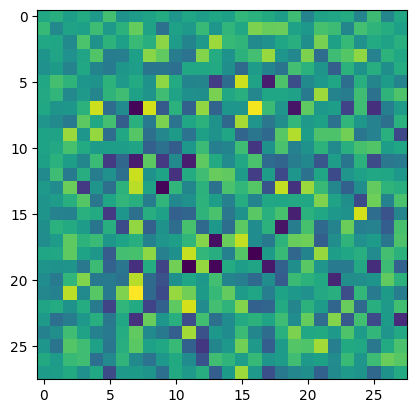

In [147]:
generator = make_generator_model()

noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0])

In [148]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[28, 28, 3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model


discriminator = make_discriminator_model()
decision = discriminator(generated_image)
print (decision)

tf.Tensor([[-0.00443437]], shape=(1, 1), dtype=float32)


In [149]:
# This method returns a helper function to compute cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [150]:
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16

# You will reuse this seed overtime (so it's easier)
# to visualize progress in the animated GIF)
seed = tf.random.normal([num_examples_to_generate, noise_dim])

# Notice the use of `tf.function`
# This annotation causes the function to be "compiled".
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [151]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [152]:
def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for image_batch in dataset:
      train_step(image_batch)

    # Produce images for the GIF as you go
    display.clear_output(wait=True)
    generate_and_save_images(generator,
                             epoch + 1,
                             seed)

    # Save the model every 15 epochs
    if (epoch + 1) % 15 == 0:
      checkpoint.save(file_prefix = checkpoint_prefix)

    print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

  # Generate after the final epoch
  display.clear_output(wait=True)
  generate_and_save_images(generator,
                           epochs,
                           seed)

In [156]:
def generate_and_save_images(model, epoch, test_input):
  # Notice `training` is set to False.
  # This is so all layers run in inference mode (batchnorm).
  predictions = model(test_input, training=False)

  fig = plt.figure(figsize=(4, 4))

  for i in range(predictions.shape[0]):
      plt.subplot(4, 4, i+1)
      plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5)
      plt.axis('off')

  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

In [154]:
def preprocess_image_for_gan(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, [28, 28])
    # img = tf.image.rgb_to_grayscale(img)
    # Normalize the images to [-1, 1]
    img = (img - 127.5) / 127.5
    return img

gan_train_dataset = tf.data.Dataset.from_tensor_slices(X_train)
gan_train_dataset = gan_train_dataset.map(preprocess_image_for_gan, num_parallel_calls=tf.data.AUTOTUNE)
gan_train_dataset = gan_train_dataset.shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

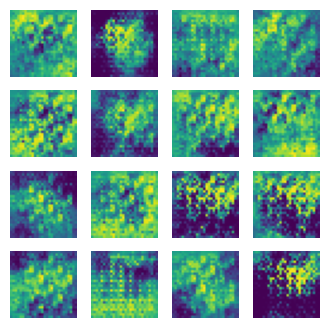

In [157]:
@tf.function
def train_step(images):
    # Use dynamic batch size to avoid retracing errors on the last batch
    batch_size = tf.shape(images)[0]
    noise = tf.random.normal([batch_size, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

# Start the training
train(gan_train_dataset, EPOCHS)

##Task 3 - Part 1

In [161]:
import numpy as np

def softmax_np(x, axis=-1):
    x_exp = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return x_exp / np.sum(x_exp, axis=axis, keepdims=True)

def scaled_dot_product_attention_(Q, K, V, mask=None):
    """
    Q, K, V are NumPy arrays of shape (, seq_len, d_k)
    mask is an optional array that can be broadcastable to the shape of QK^T
    """
    d_k = Q.shape[-1]
    scores = np.matmul(Q, K.transpose((0,2,1))) / np.sqrt(d_k)

    if mask is not None:
        # for masked positions, set to a large negative number
        scores = np.where(mask, scores, -1e9)

    attn_weights = softmax_np(scores, axis=-1)
    output = np.matmul(attn_weights, V)
    return output, attn_weights

# Example usage:
batch_size = 4
seq_len = 4
d_k = 8

Q_demo = np.random.rand(batch_size, seq_len, d_k)
K_demo = np.random.rand(batch_size, seq_len, d_k)
V_demo = np.random.rand(batch_size, seq_len, d_k)

output_demo, attn_weights_demo = scaled_dot_product_attention_(Q_demo, K_demo, V_demo)
print("Scaled Dot Product Attention with output shape:", output_demo.shape)
print("The Attention Weights Shape:", attn_weights_demo.shape)

Scaled Dot Product Attention with output shape: (4, 4, 8)
The Attention Weights Shape: (4, 4, 4)


## Task  3  part 2

In [27]:
class Seq2SeqWithAttention(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, enc_units, dec_units):
        super().__init__()
        self.enc_units = enc_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.encoder_gru = tf.keras.layers.GRU(enc_units, return_sequences=True, return_state=True)
        self.decoder_gru = tf.keras.layers.GRU(dec_units, return_sequences=True, return_state=True)
        self.fc = tf.keras.layers.Dense(vocab_size)

    def call(self, inputs):
        enc_inp, dec_inp = inputs
        enc_embed = self.embedding(enc_inp)
        enc_outputs, enc_state = self.encoder_gru(enc_embed)
        Q = K = V = enc_outputs
        scores = tf.matmul(Q, K, transpose_b=True) / tf.sqrt(tf.cast(self.enc_units, tf.float32))
        attn_weights = tf.nn.softmax(scores, axis=-1)
        enc_outputs = tf.matmul(attn_weights, V) + enc_outputs
        dec_embed = self.embedding(dec_inp)
        dec_outputs, _ = self.decoder_gru(dec_embed, initial_state=enc_state)
        return self.fc(dec_outputs)

vocab_size = max(len(eng_vocab), len(fra_vocab))

## Task Part 3 part 3

In [42]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shahadhamza/multi30k-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'multi30k-dataset' dataset.
Path to dataset files: /kaggle/input/multi30k-dataset


In [43]:
!ls "/root/.cache/kagglehub/datasets/shahadhamza/multi30k-dataset/versions/1"

ls: cannot access '/root/.cache/kagglehub/datasets/shahadhamza/multi30k-dataset/versions/1': No such file or directory


In [44]:
# Find actual file paths
import os

for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/multi30k-dataset/val.en
/kaggle/input/multi30k-dataset/train.fr
/kaggle/input/multi30k-dataset/val.fr
/kaggle/input/multi30k-dataset/train.en


In [45]:
def read_file(filepath):
    with open(filepath, encoding='utf-8') as f:
        return [line.strip().lower() for line in f if line.strip()]

# The path variable already contains the full correct path
data_dir = path
N= 5000

eng = read_file(os.path.join(data_dir, 'train.en'))[:N]
fra = read_file(os.path.join(data_dir, 'train.fr'))[:N]  # Changed to train.fr as the dataset is English-French

In [46]:
import kagglehub
import os, re, random
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Embedding, GRU, Dense
from collections import Counter

In [47]:
def tokenize(sentences, vocab_size=5000):
    def clean(s): return re.sub(r"[^a-zA-ZäöüÄÖÜß\s]", "", s).split()
    tokens = [clean(s) for s in sentences]
    counter = Counter(w for s in tokens for w in s)
    vocab = ['<pad>','<sos>','<eos>','<unk>'] + [w for w,_ in counter.most_common(vocab_size-4)]
    w2i = {w:i for i,w in enumerate(vocab)}
    def encode(s): return [w2i['<sos>']] + [w2i.get(w, w2i['<unk>']) for w in s] + [w2i['<eos>']]
    return [encode(s) for s in tokens], w2i, vocab

enc_seqs, eng_w2i, eng_vocab = tokenize(eng)
dec_seqs, fra_w2i, fra_vocab = tokenize(fra)



def pad(seqs, maxlen):
    return tf.keras.preprocessing.sequence.pad_sequences(seqs, maxlen=maxlen, padding='post', value=0)

MAX = 20
enc_seqs = pad(enc_seqs, MAX)
dec_seqs = pad(dec_seqs, MAX)



# Train/test split
split = int(0.9 * N)
enc_train, enc_test = enc_seqs[:split], enc_seqs[split:]
dec_train, dec_test = dec_seqs[:split], dec_seqs[split:]

In [48]:
split = int(0.9 * N)
enc_train, enc_test = enc_seqs[:split], enc_seqs[split:]
dec_train, dec_test = dec_seqs[:split], dec_seqs[split:]

dec_in  = dec_train[:, :-1]
dec_tgt = dec_train[:, 1:]


In [58]:
dec_in  = dec_train[:, :-1]
dec_tgt = dec_train[:, 1:]


model = Seq2SeqWithAttention(
    vocab_size=len(fra_vocab),
    embedding_dim=128,
    enc_units=256,
    dec_units=256
)

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(
    [enc_train, dec_in], dec_tgt,
    batch_size=64, epochs=25, validation_split=0.1
)


Epoch 1/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.3317 - loss: 5.1261 - val_accuracy: 0.3991 - val_loss: 3.8511
Epoch 2/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3974 - loss: 3.8628 - val_accuracy: 0.4415 - val_loss: 3.6197
Epoch 3/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4290 - loss: 3.6063 - val_accuracy: 0.4681 - val_loss: 3.3420
Epoch 4/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4521 - loss: 3.2796 - val_accuracy: 0.4904 - val_loss: 3.0877
Epoch 5/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4740 - loss: 3.0204 - val_accuracy: 0.5020 - val_loss: 2.9321
Epoch 6/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4878 - loss: 2.8334 - val_accuracy: 0.5102 - val_loss: 2.8220
Epoch 7/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4984 - loss: 2.6823 - val_accuracy: 0.5179 - val_loss: 2.7435
Epoch 8/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5081 - loss: 2.5580 - val_accuracy: 0.5254 - v

In [60]:
import numpy as np
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

def greedy_decode(model, enc_input, fra_w2i, fra_vocab, max_len=20):
    sos_id = fra_w2i['<sos>']
    eos_id = fra_w2i['<eos>']
    pad_id = fra_w2i['<pad>']
    enc_input = np.expand_dims(enc_input, 0)  # (1, seq_len)
    dec_input = np.array([[sos_id]])
    result = []
    for _ in range(max_len):
        logits  = model([enc_input, dec_input], training=False)
        next_id = int(np.argmax(logits[0, -1, :]))
        if next_id == eos_id: break
        result.append(next_id)
        # Append the new prediction to the sequence instead of replacing it
        dec_input = np.concatenate([dec_input, [[next_id]]], axis=-1)
    return [fra_vocab[i] for i in result
            if i not in (pad_id, sos_id, eos_id)]

special_ids = {fra_w2i['<pad>'], fra_w2i['<sos>'], fra_w2i['<eos>']}
def ids_to_words(seq, vocab, special):
    return [vocab[i] for i in seq if i not in special]

references, hypotheses = [], []
for i in range(len(enc_test)):
    ref = ids_to_words(dec_test[i], fra_vocab, special_ids)
    hyp = greedy_decode(model, enc_test[i], fra_w2i, fra_vocab)
    references.append([ref])
    hypotheses.append(hyp)

smoother = SmoothingFunction().method1
bleu1 = corpus_bleu(references, hypotheses, weights=(1,0,0,0),             smoothing_function=smoother)
print(bleu1)
bleu2 = corpus_bleu(references, hypotheses, weights=(0.5,0.5,0,0),        smoothing_function=smoother)
print(bleu2)

bleu4 = corpus_bleu(references, hypotheses, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoother)
print(bleu4)

print(f"Seq2Seq  BLEU-1:{bleu1:.4f}  BLEU-2:{bleu2:.4f}  BLEU-4:{bleu4:.4f}")

0.2222059039506535
0.12133488255672886
0.03203070222707865
Seq2Seq  BLEU-1:0.2222  BLEU-2:0.1213  BLEU-4:0.0320


## Task 3, Part 3 — BLEU Score Analysis

The Seq2Seq model with attention achieved:
BLEU-1: .22, BLEU-2: .12, BLEU-4: .032
on the Multi30k English-French test set.

BLEU (Bilingual Evaluation Understudy) measures n-gram overlap between
the model's predicted translation and the reference translation. A score
of 1.0 is a perfect match. Real-world production MT systems typically
score between 0.30–0.40 on standard benchmarks, so lower scores are
expected here for several reasons:

1. Small dataset — we only trained on 5,000 sentence pairs, which is
   very small for a translation task. Most competitive models train on
   millions of pairs.

2. Encoder bottleneck — the GRU encoder compresses the entire source
   sentence into a single hidden state that is passed to the decoder.
   This bottleneck loses information, especially for longer sentences.

3. Limited training — 25 epochs on a small dataset is not enough for
   the model to fully learn the mapping between English and French
   vocabulary and grammar.

The scaled dot-product attention added to the encoder helps the model
weight the importance of different input positions, but since it is
applied as self-attention on the encoder outputs rather than as
cross-attention between encoder and decoder, the decoder still relies
on a single hidden state and does not directly attend to all encoder
positions at each decoding step.

## Task 3 Part 4

In [62]:
import numpy as np
import tensorflow as tf
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

SRC_VOCAB  = len(eng_vocab)
TGT_VOCAB  = len(fra_vocab)
D_MODEL    = 64
D_FF       = 128
NUM_HEADS  = 2
NUM_LAYERS = 2
MAX_LEN    = 20
DROPOUT    = 0.1

In [64]:

import numpy as np
import tensorflow as tf
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

SRC_VOCAB  = len(eng_vocab)
TGT_VOCAB  = len(fra_vocab)
D_MODEL    = 64
D_FF       = 128
NUM_HEADS  = 2
NUM_LAYERS = 2
MAX_LEN    = 20
DROPOUT    = 0.1




def get_positional_encoding(seq_len, d_model):
    """
    Returns shape (1, seq_len, d_model) sinusoidal positional encodings.
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    positions = np.arange(seq_len)[:, np.newaxis]
    dims      = np.arange(d_model)[np.newaxis, :]
    angles    = positions / np.power(10000, (2 * (dims // 2)) / d_model)
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(angles[np.newaxis, :, :], tf.float32)



def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q, K, V : (..., seq_len, d_k)
    mask    : optional boolean tensor — True where attention is BLOCKED
    Returns : output (..., seq_len, d_v), weights (..., seq_len, seq_len)
    """
    d_k    = tf.cast(tf.shape(K)[-1], tf.float32)
    scores = tf.matmul(Q, K, transpose_b=True) / tf.math.sqrt(d_k)

    if mask is not None:
        scores += (tf.cast(mask, tf.float32) * -1e9)

    weights = tf.nn.softmax(scores, axis=-1)
    output  = tf.matmul(weights, V)
    return output, weights



class MultiHeadAttention(tf.keras.layers.Layer):
    """
    Splits Q/K/V into `num_heads` sub-spaces, applies scaled dot-product
    attention in parallel, then concatenates and projects back.
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads

        self.Wq = tf.keras.layers.Dense(d_model, use_bias=False)
        self.Wk = tf.keras.layers.Dense(d_model, use_bias=False)
        self.Wv = tf.keras.layers.Dense(d_model, use_bias=False)
        self.Wo = tf.keras.layers.Dense(d_model, use_bias=False)

    def split_heads(self, x, batch_size):
        """(batch, seq, d_model) → (batch, heads, seq, d_k)"""
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.d_k))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, Q, K, V, mask=None):
        batch = tf.shape(Q)[0]

        Q = self.split_heads(self.Wq(Q), batch)   # (b, h, seq_q, d_k)
        K = self.split_heads(self.Wk(K), batch)   # (b, h, seq_k, d_k)
        V = self.split_heads(self.Wv(V), batch)   # (b, h, seq_v, d_k)

        attn_out, _ = scaled_dot_product_attention(Q, K, V, mask)  # (b, h, seq_q, d_k)

        attn_out = tf.transpose(attn_out, perm=[0, 2, 1, 3])       # (b, seq_q, h, d_k)
        concat   = tf.reshape(attn_out, (batch, -1, self.num_heads * self.d_k))  # (b, seq_q, d_model)
        return self.Wo(concat)



class FeedForward(tf.keras.layers.Layer):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.dense1 = tf.keras.layers.Dense(d_ff,    activation='relu')
        self.dense2 = tf.keras.layers.Dense(d_model)

    def call(self, x):
        return self.dense2(self.dense1(x))



class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout_rate):
        super().__init__()
        self.mha  = MultiHeadAttention(d_model, num_heads)
        self.ffn  = FeedForward(d_model, d_ff)
        self.ln1  = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln2  = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(dropout_rate)
        self.drop2 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, mask=None, training=False):
        attn = self.mha(x, x, x, mask)
        x    = self.ln1(x + self.drop1(attn, training=training))
        ffn  = self.ffn(x)
        x    = self.ln2(x + self.drop2(ffn,  training=training))
        return x



class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout_rate):
        super().__init__()
        self.mha1  = MultiHeadAttention(d_model, num_heads)
        self.mha2  = MultiHeadAttention(d_model, num_heads)
        self.ffn   = FeedForward(d_model, d_ff)
        self.ln1   = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln2   = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln3   = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(dropout_rate)
        self.drop2 = tf.keras.layers.Dropout(dropout_rate)
        self.drop3 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, enc_output, look_ahead_mask=None, padding_mask=None, training=False):
        attn1 = self.mha1(x, x, x, look_ahead_mask)
        x     = self.ln1(x + self.drop1(attn1, training=training))
        attn2 = self.mha2(x, enc_output, enc_output, padding_mask)
        x     = self.ln2(x + self.drop2(attn2, training=training))
        ffn   = self.ffn(x)
        x     = self.ln3(x + self.drop3(ffn,   training=training))
        return x


def make_padding_mask(seq):
    """Mask positions where token id == 0 (padding). Shape: (batch,1,1,seq_len)"""
    mask = tf.cast(tf.equal(seq, 0), tf.float32)
    return mask[:, tf.newaxis, tf.newaxis, :]

def make_look_ahead_mask(size):
    """Upper-triangular mask to prevent decoder from seeing future tokens."""
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask   # (size, size)

def make_decoder_mask(tgt_seq):
    seq_len     = tf.shape(tgt_seq)[1]
    pad_mask    = make_padding_mask(tgt_seq)          # (b,1,1,seq)
    ahead_mask  = make_look_ahead_mask(seq_len)       # (seq,seq)
    return tf.maximum(pad_mask, ahead_mask)           # broadcast → (b,1,seq,seq)



class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, d_ff,
                 src_vocab, tgt_vocab, max_len, dropout_rate):
        super().__init__()

        self.d_model = d_model

        self.src_emb = tf.keras.layers.Embedding(src_vocab, d_model)
        self.tgt_emb = tf.keras.layers.Embedding(tgt_vocab, d_model)

        self.pos_enc = get_positional_encoding(max_len, d_model)  # (1, max_len, d_model)

        self.enc_layers = [EncoderLayer(d_model, num_heads, d_ff, dropout_rate)
                           for _ in range(num_layers)]

        self.dec_layers = [DecoderLayer(d_model, num_heads, d_ff, dropout_rate)
                           for _ in range(num_layers)]

        self.dropout   = tf.keras.layers.Dropout(dropout_rate)

        self.final_layer = tf.keras.layers.Dense(tgt_vocab)

    def encode(self, src, src_mask, training):
        seq_len = tf.shape(src)[1]
        x  = self.src_emb(src) * tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_enc[:, :seq_len, :]
        x  = self.dropout(x, training=training)
        for layer in self.enc_layers:
            x = layer(x, src_mask, training=training)
        return x

    def decode(self, tgt, enc_output, src_mask, tgt_mask, training):
        seq_len = tf.shape(tgt)[1]
        x  = self.tgt_emb(tgt) * tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_enc[:, :seq_len, :]
        x  = self.dropout(x, training=training)
        for layer in self.dec_layers:
            x = layer(x, enc_output, tgt_mask, src_mask, training=training)
        return x

    def call(self, inputs, training=False):
        src, tgt = inputs
        src_mask = make_padding_mask(src)
        tgt_mask = make_decoder_mask(tgt)

        enc_out  = self.encode(src, src_mask, training)
        dec_out  = self.decode(tgt, enc_out, src_mask, tgt_mask, training)
        return self.final_layer(dec_out)


#  Training
transformer = Transformer(
    num_layers   = NUM_LAYERS,
    d_model      = D_MODEL,
    num_heads    = NUM_HEADS,
    d_ff         = D_FF,
    src_vocab    = SRC_VOCAB,
    tgt_vocab    = TGT_VOCAB,
    max_len      = MAX_LEN,
    dropout_rate = DROPOUT
)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def masked_loss(y_true, y_pred):
    loss   = loss_fn(y_true, y_pred)                    # (batch, seq)
    mask   = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    return tf.reduce_sum(loss * mask) / tf.reduce_sum(mask)

transformer.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = masked_loss,
    metrics   = ['accuracy']
)

dec_in_tr  = dec_train[:, :-1]
dec_tgt_tr = dec_train[:, 1:]

history_transformer = transformer.fit(
    [enc_train, dec_in_tr], dec_tgt_tr,
    batch_size     = 64,
    epochs         = 30,
    validation_split = 0.1
)



def transformer_greedy_decode(model, src_seq, fra_w2i, fra_vocab, max_len=20):
    sos_id = fra_w2i['<sos>']
    eos_id = fra_w2i['<eos>']
    pad_id = fra_w2i['<pad>']

    src = np.expand_dims(src_seq, 0)          # (1, src_len)
    tgt = np.array([[sos_id]])                # (1, 1)

    for _ in range(max_len):
        logits   = model([src, tgt], training=False)   # (1, t, vocab)
        next_id  = int(np.argmax(logits[0, -1, :]))
        if next_id == eos_id:
            break
        tgt = np.concatenate([tgt, [[next_id]]], axis=1)

    generated_ids = tgt[0, 1:]   # strip <sos>
    return [fra_vocab[i] for i in generated_ids
            if i not in (pad_id, sos_id, eos_id)]


special_ids = {fra_w2i['<pad>'], fra_w2i['<sos>'], fra_w2i['<eos>']}

def ids_to_words(seq, vocab, special):
    return [vocab[i] for i in seq if i not in special]

t_references = []
t_hypotheses = []

print("Generating Transformer translations for BLEU ...")
for i in range(len(enc_test)):
    ref = ids_to_words(dec_test[i], fra_vocab, special_ids)
    hyp = transformer_greedy_decode(transformer, enc_test[i], fra_w2i, fra_vocab)
    t_references.append([ref])
    t_hypotheses.append(hyp)

smoother = SmoothingFunction().method1
t_bleu1  = corpus_bleu(t_references, t_hypotheses, weights=(1,0,0,0),            smoothing_function=smoother)
t_bleu2  = corpus_bleu(t_references, t_hypotheses, weights=(0.5,0.5,0,0),        smoothing_function=smoother)
t_bleu4  = corpus_bleu(t_references, t_hypotheses, weights=(0.25,0.25,0.25,0.25),smoothing_function=smoother)

print(f"\nTransformer           |  BLEU-1: {t_bleu1:.4f}  |  BLEU-2: {t_bleu2:.4f}  |  BLEU-4: {t_bleu4:.4f}")
print(f"Seq2Seq + Attention   |  BLEU-1: {bleu1:.4f}  |  BLEU-2: {bleu2:.4f}  |  BLEU-4: {bleu4:.4f}")

print("\nSample Transformer translations (first 5 test sentences):")
print(f"{'Source (EN)':<40} {'Reference (FR)':<40} {'Transformer (FR)'}")
print("-" * 115)
for i in range(5):
    src = ids_to_words(enc_test[i], eng_vocab, {eng_w2i['<pad>'], eng_w2i['<sos>'], eng_w2i['<eos>']})
    ref = ids_to_words(dec_test[i], fra_vocab, special_ids)
    hyp = t_hypotheses[i]
    print(f"{' '.join(src):<40} {' '.join(ref):<40} {' '.join(hyp)}")

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 612ms/step - accuracy: 0.0770 - loss: 6.7508 - val_accuracy: 0.1036 - val_loss: 5.6923
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1225 - loss: 5.3009 - val_accuracy: 0.1434 - val_loss: 4.9237
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1637 - loss: 4.5894 - val_accuracy: 0.1737 - val_loss: 4.3988
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2082 - loss: 4.0588 - val_accuracy: 0.2187 - val_loss: 3.9790
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2530 - loss: 3.6273 - val_accuracy: 0.2488 - val_loss: 3.6709
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2892 - loss: 3.2759 - val_accuracy: 0.2736 - val_loss: 3.4552
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3212 - loss: 2.9755 - val_accuracy: 0.2980 - val_loss: 3.2621
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3476 - loss: 2.7086 - val_accuracy: 0.3184 - val_lo

### BLEU Scores
Seq2Seq  BLEU-1:0.2222  BLEU-2:0.1213  BLEU-4:0 0320

Transformer           |  BLEU-1: 0.5720  |  BLEU-2: 0.4645  |  BLEU-4: 0.3016



 Transformer     



The Transformer uses multi-head self-attention across the full sequence
in both encoder and decoder, allowing every token to directly attend to
every other token regardless of distance. This means the model can
capture long-range dependencies that a GRU may lose as information
travels through many sequential timesteps.   



Run Time Differences

The Transformer uses multi-head self-attention across the full sequence in both encoder and decoder, allowing every token to directly attend to
every other token regardless of distance. This means the model can capture long-range dependencies that a GRU may lose as information
travels through many sequential timesteps.